# 문장분류를 위한 CNN모델
'문장'을 '감정 클래스별'로 분류하는CNN 모델 구현
- CNN 은 이미지 분류 외에도 자연어 분류에도 좋은 성능을 냅니다 (단 **임베딩 품질**이 좋아야 함.)
- 이미지 이든, 자연어이든  수치(벡터) 로 표현 가능한 대상이면, 특징을 뽑아내도록 CNN 모델 학습이 가능한겁니다

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# import

In [6]:
# 필요한 모듈 임포트
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import preprocessing

# 실행마다 동일한 결과를 얻기 위해 keras 에 랜덤시드 사용
def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  tf.config.experimental.enable_op_determinism()


# CNN 모델 생성용 ↓
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Conv1D, GlobalMaxPool1D, concatenate



# 1.데이터 준비

In [7]:
base_path = r'/content/drive/MyDrive/KDT-2604/dataset/chatbot'


In [8]:
# 데이터 읽어오기
data = pd.read_csv(os.path.join(base_path, 'chatbot_data.csv'))
data

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


- 데이터셋 구조
    - Q (질문),  
    - A (답변)
    - label (감정)
        - **0**: 일상다반사
        - **1** : 이별(부정)
        - **2** : 사랑(긍정)

In [9]:
data.shape

(11823, 3)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [11]:
data['label'].unique() # 레이블에 어떠한 분류값들이 있는지 확인하기

array([0, 1, 2])

In [12]:
data['label'].value_counts()  # 각 분류(class) 별로 데이터의 개수들

,count
label,
0,5290
1,3570
2,2963


In [13]:
# 입력데이터(features) 와 타겟(labels) 분리
features = data['Q'].tolist()
labels = data['label'].tolist()

# 첫번째 샘플 확인
print(features[0])
print(labels[0])

12시 땡!
0


# 2.단어 시퀀스 만들기


## text_to_word_sequence()

**tf.keras.preprocessing.text.text_to_word_sequence()**

단어 시퀀스를 만든다.  단어 시퀀스란 단어 토큰들의 순차적 리스트

https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/text_to_word_sequence

```python
tf.keras.preprocessing.text.text_to_word_sequence(
    input_text,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' '
)
```

리턴값: A list of words (or tokens).

In [14]:
# 첫번째 샘플에 대한 단어 시퀀스
preprocessing.text.text_to_word_sequence(features[0])

['12시', '땡']

In [15]:
# 단어 시퀀스 들의 벡터

corpus = [
   preprocessing.text.text_to_word_sequence(text) for text in features
]

corpus

[['12시', '땡'],
 ['1지망', '학교', '떨어졌어'],
 ['3박4일', '놀러가고', '싶다'],
 ['3박4일', '정도', '놀러가고', '싶다'],
 ['ppl', '심하네'],
 ['sd카드', '망가졌어'],
 ['sd카드', '안돼'],
 ['sns', '맞팔', '왜', '안하지ㅠㅠ'],
 ['sns', '시간낭비인', '거', '아는데', '매일', '하는', '중'],
 ['sns', '시간낭비인데', '자꾸', '보게됨'],
 ['sns보면', '나만', '빼고', '다', '행복해보여'],
 ['가끔', '궁금해'],
 ['가끔', '뭐하는지', '궁금해'],
 ['가끔은', '혼자인게', '좋다'],
 ['가난한', '자의', '설움'],
 ['가만', '있어도', '땀난다'],
 ['가상화폐', '쫄딱', '망함'],
 ['가스불', '켜고', '나갔어'],
 ['가스불', '켜놓고', '나온거', '같아'],
 ['가스비', '너무', '많이', '나왔다'],
 ['가스비', '비싼데', '감기', '걸리겠어'],
 ['가스비', '장난', '아님'],
 ['가장', '확실한', '건', '뭘까'],
 ['가족', '여행', '가기로', '했어'],
 ['가족', '여행', '고고'],
 ['가족', '여행', '어디로', '가지'],
 ['가족', '있어'],
 ['가족관계', '알려', '줘'],
 ['가족끼리', '여행간다'],
 ['가족들', '보고', '싶어'],
 ['가족들이랑', '서먹해'],
 ['가족들이랑', '서먹해졌어'],
 ['가족들이랑', '어디', '가지'],
 ['가족들이랑', '여행', '갈거야'],
 ['가족여행', '가야지'],
 ['가족이', '누구야'],
 ['가족이랑', '여행', '가려고'],
 ['가족한테', '스트레스', '풀었어'],
 ['가출할까'],
 ['가출해도', '갈', '데가', '없어'],
 ['간만에', '떨리니까', '좋더라'],
 ['간만에', '쇼핑', '

## Tokenizer 객체
**tf.keras.preprocessing.text.Tokenizer**


https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer


```python
tf.keras.preprocessing.text.Tokenizer(
    num_words=None,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' ',
    char_level=False,
    oov_token=None,
    analyzer=None,
    **kwargs
)
```


In [16]:
tokenizer = preprocessing.text.Tokenizer()

### fit_on_texts()

- 주어진 text  기반으로 Tokenizer 내부 어휘 update 수행
- texts_to_sequences 나 texts_to_matrix 호출전에 반드시 먼저 호출해야 한다

https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer#fit_on_texts

```python
fit_on_texts(
    texts
)
```

In [17]:
# 단어 시퀀스 벡터를 매개변수로 사전구축  word -> index
tokenizer.fit_on_texts(corpus)

In [18]:
corpus  # 매개변수가 변한게 아니다.

[['12시', '땡'],
 ['1지망', '학교', '떨어졌어'],
 ['3박4일', '놀러가고', '싶다'],
 ['3박4일', '정도', '놀러가고', '싶다'],
 ['ppl', '심하네'],
 ['sd카드', '망가졌어'],
 ['sd카드', '안돼'],
 ['sns', '맞팔', '왜', '안하지ㅠㅠ'],
 ['sns', '시간낭비인', '거', '아는데', '매일', '하는', '중'],
 ['sns', '시간낭비인데', '자꾸', '보게됨'],
 ['sns보면', '나만', '빼고', '다', '행복해보여'],
 ['가끔', '궁금해'],
 ['가끔', '뭐하는지', '궁금해'],
 ['가끔은', '혼자인게', '좋다'],
 ['가난한', '자의', '설움'],
 ['가만', '있어도', '땀난다'],
 ['가상화폐', '쫄딱', '망함'],
 ['가스불', '켜고', '나갔어'],
 ['가스불', '켜놓고', '나온거', '같아'],
 ['가스비', '너무', '많이', '나왔다'],
 ['가스비', '비싼데', '감기', '걸리겠어'],
 ['가스비', '장난', '아님'],
 ['가장', '확실한', '건', '뭘까'],
 ['가족', '여행', '가기로', '했어'],
 ['가족', '여행', '고고'],
 ['가족', '여행', '어디로', '가지'],
 ['가족', '있어'],
 ['가족관계', '알려', '줘'],
 ['가족끼리', '여행간다'],
 ['가족들', '보고', '싶어'],
 ['가족들이랑', '서먹해'],
 ['가족들이랑', '서먹해졌어'],
 ['가족들이랑', '어디', '가지'],
 ['가족들이랑', '여행', '갈거야'],
 ['가족여행', '가야지'],
 ['가족이', '누구야'],
 ['가족이랑', '여행', '가려고'],
 ['가족한테', '스트레스', '풀었어'],
 ['가출할까'],
 ['가출해도', '갈', '데가', '없어'],
 ['간만에', '떨리니까', '좋더라'],
 ['간만에', '쇼핑', '

### texts_to_sequences()
- 문장내 모든 단어를 시퀀스 번호로 변환
- https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer#texts_to_sequences
```python
texts_to_sequences(
    texts
)
```



In [19]:
# texts_to_sequences() :
#  Tokenizer 내 구축된 사전을 사용하여
#  문장내 모든 단어 시퀀스 를  정수 인덱스 시퀀스 로 변환
#  ※ 변환된 시퀀스 번호를 이용하여 단어 임베딩 벡터를 만들거다

sequences = tokenizer.texts_to_sequences(corpus)
sequences

[[4646, 4647],
 [4648, 343, 448],
 [2580, 803, 11],
 [2580, 804, 803, 11],
 [4649, 2581],
 [2582, 4650],
 [2582, 64],
 [805, 4651, 14, 4652],
 [805, 4653, 3, 502, 238, 45, 106],
 [805, 4654, 23, 4655],
 [4656, 52, 1128, 28, 1373],
 [693, 266],
 [693, 2583, 266],
 [2584, 4657, 324],
 [4658, 4659, 4660],
 [4661, 1129, 2585],
 [4662, 4663, 1374],
 [2586, 4664, 1375],
 [2586, 4665, 2587, 5],
 [1811, 1, 27, 4666],
 [1811, 2588, 1130, 4667],
 [1811, 628, 1131],
 [944, 1812, 154, 128],
 [1132, 176, 1376, 184],
 [1132, 176, 1133],
 [1132, 176, 945, 1813],
 [1132, 25],
 [2589, 4668, 503],
 [2590, 4669],
 [4670, 94, 4],
 [1377, 4671],
 [1377, 4672],
 [1377, 368, 1813],
 [1377, 176, 4673],
 [4674, 280],
 [2591, 1378],
 [4675, 176, 1379],
 [2592, 253, 4676],
 [4677],
 [4678, 504, 1380, 20],
 [1381, 4679, 1814],
 [1381, 1134, 106],
 [1381, 2593, 106],
 [1815, 41, 405],
 [1815, 254],
 [4680, 2594],
 [4681, 75],
 [325, 505, 308, 67],
 [325, 505],
 [2595, 2596, 53, 11],
 [2595, 2596, 185],
 [1130, 109

In [20]:
# 0번째 문장의 '단어시퀀스' 와 '정수 인덱스 시퀀스' 비교
corpus[0], sequences[0]

(['12시', '땡'], [4646, 4647])

In [21]:
corpus[8], sequences[8]

(['sns', '시간낭비인', '거', '아는데', '매일', '하는', '중'],
 [805, 4653, 3, 502, 238, 45, 106])

### `.word_index` 단어 사전
- `fit_on_text()` 를 통해 Tokenizer 에 구축된 단어사전
- dict

In [22]:
# 단어별 시퀀스 번호 확인 가능
word_index = tokenizer.word_index
print(len(word_index))
word_index

13398


{'너무': 1,
 '좋아하는': 2,
 '거': 3,
 '싶어': 4,
 '같아': 5,
 '안': 6,
 '나': 7,
 '좀': 8,
 '사람': 9,
 '내가': 10,
 '싶다': 11,
 '어떻게': 12,
 '썸': 13,
 '왜': 14,
 '내': 15,
 '사람이': 16,
 '이별': 17,
 '것': 18,
 '잘': 19,
 '없어': 20,
 '수': 21,
 '오늘': 22,
 '자꾸': 23,
 '이제': 24,
 '있어': 25,
 '또': 26,
 '많이': 27,
 '다': 28,
 '있을까': 29,
 '헤어진지': 30,
 '해': 31,
 '다시': 32,
 '될까': 33,
 '여자친구가': 34,
 '남자친구가': 35,
 '더': 36,
 '진짜': 37,
 '정말': 38,
 '게': 39,
 '나를': 40,
 '뭐': 41,
 '좋아': 42,
 '할까': 43,
 '하고': 44,
 '하는': 45,
 '연애': 46,
 '있는': 47,
 '계속': 48,
 '힘드네': 49,
 '연락': 50,
 '이': 51,
 '나만': 52,
 '먹고': 53,
 '이렇게': 54,
 '있는데': 55,
 '못': 56,
 '날': 57,
 '혼자': 58,
 '다른': 59,
 '방법': 60,
 '타는': 61,
 '한': 62,
 '그': 63,
 '안돼': 64,
 '그냥': 65,
 '없는': 66,
 '돼': 67,
 '짝남이': 68,
 '좋겠다': 69,
 '선물': 70,
 '모르겠어': 71,
 '같이': 72,
 '나한테': 73,
 '같은데': 74,
 '싫어': 75,
 '친구가': 76,
 '마음이': 77,
 '짝사랑': 78,
 '가고': 79,
 '사랑': 80,
 '헤어진': 81,
 '많아': 82,
 '힘들어': 83,
 '연락이': 84,
 '줄': 85,
 '좋겠어': 86,
 '술': 87,
 '후': 88,
 '짝남': 89,
 '듯': 90,
 '좋은': 91,
 '좋을까

위 단계를 그림으로 나타낸 설명

![](https://www.dropbox.com/scl/fi/naoy6jn9folrovckr5jko/1.png?rlkey=u4lm8pivjz0v1hy4njmmvbucw&st=8qlc1rxb&dl=1)

In [23]:
# 다른 문장으로 테스트 해보면
tokenizer.texts_to_sequences([['여기', '어때'], ['정말', '좋아'], ['온달', '장군']])
# [[2147, 108], [38, 42], []]

# Tokenizer 에 인덱싱이 되어 있지 않은 단어들(OOV)은 sequence 에서 제외된다.

[[2147, 108], [38, 42], []]

## 시퀀스 번호로 만든 벡터의 문제점
** 문장의 길이가 제각각 이라 벡터 크기가 다 다르다. **
- 그러나! CNN 모델은 입력 계층은 고정된 개수의 입력노드다! (그림)

![](https://www.dropbox.com/scl/fi/v4v6n6jv2dp0v39tbjo9x/2.png?rlkey=xdmaoi1ws8n9j5dhllv4uboxk&st=00fax21n&dl=1)

- 그래서 넉넉한 크기의 MAX 시퀀스 길이를 잡고
- MAX 시퀀스 길이보다 작은 벡터는 0 으로 채우는 (패딩)한다  --> `pad_sequences()`
- https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences

## 패딩 pad_sequences()

**tf.keras.utils.pad_sequences**

https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences

```python
tf.keras.utils.pad_sequences(
    sequences,
    maxlen=None,
    dtype='int32',
    padding='pre',
    truncating='pre',
    value=0.0
)
```

In [24]:
# 넉넉한 MAX 크기 산출은 어떻게?
# 산출 근거는 아래와 같이..  간단히 확인  (가장 많은 개수의 토큰을 가진 문장의 토큰 개수)
# 패딩을 집어넣기 위해 최대 몇개의 토큰이 있었는지 확인하는 절차
max(len(words) for words in corpus)


15

In [25]:
# 주어진 입력 문장에서 최대 토큰 개수가 15개.   이 길이로 패딩해보자
MAX_SEQ_LEN = 15  # 단어 시퀀스 벡터 크기
# ↑ 최대 몇개의 토큰으로 구성되어 있는지 파악해야 한다.
#    너무 크게 잡으면 빈 공간이 많이 생기게 되어 메모리 낭비.
#    너무 작게 잡으면 입력 데이터가 손실될 위험.

In [26]:
padded_seqs = preprocessing.sequence.pad_sequences(
    sequences, maxlen=MAX_SEQ_LEN, padding='post'
)

print(padded_seqs.shape)
padded_seqs



(11823, 15)


array([[ 4646,  4647,     0, ...,     0,     0,     0],
       [ 4648,   343,   448, ...,     0,     0,     0],
       [ 2580,   803,    11, ...,     0,     0,     0],
       ...,
       [13395,  2517,    89, ...,     0,     0,     0],
       [  147,    46,    91, ...,     0,     0,     0],
       [  555, 13398,     0, ...,     0,     0,     0]], dtype=int32)

In [27]:
# padding옵셥값
# 'pre' : 앞쪽에 패딩이 붙는다  (디폴트, RNN 등에선 이를 사용)
# 'post': 뒤쪽에 패딩이 붙는다   (여기선 post 사용, CNN 을 사용할거다 )

In [28]:
print(features[0])
print(corpus[0])
print(sequences[0])
print(padded_seqs[0])


12시 땡!
['12시', '땡']
[4646, 4647]
[4646 4647    0    0    0    0    0    0    0    0    0    0    0    0
    0]


# 3.Dataset 객체 만들기

In [29]:
# 입력: padded_seqs
# 타겟: 감정 labels

# 위 입력과 타겟을 Dataset 객체로 만든다.
# 랜덤으로 섞고,
# train:validation:test = 7:2:1 분리
# batch 로 묶기


In [30]:
# ※ train : validation : test 셋은 보통 7:2:1  혹은 6:2:2 비율로 잡습니다.
# 꼭 정해진 건 아닙니다.   여러가지 실헙해보면서 최적 비율을 찾아보도록 해야 합니다

In [31]:
# 우선 다시 확인
padded_seqs.shape

(11823, 15)

In [32]:
len(labels)

11823

In [33]:
len(features)

11823

In [34]:
# Dataset  객체 생성
ds = tf.data.Dataset.from_tensor_slices((padded_seqs, labels))
ds

<_TensorSliceDataset element_spec=(TensorSpec(shape=(15,), dtype=tf.int32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [35]:
# Dataset 의 첫번째 값 (data, target) 쌍
iter(ds).get_next()

(<tf.Tensor: shape=(15,), dtype=int32, numpy=
 array([4646, 4647,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0], dtype=int32)>,
 <tf.Tensor: shape=(), dtype=int32, numpy=0>)

In [36]:
# 랜덤 섞기
ds = ds.shuffle(len(features), seed=42)
ds

<_ShuffleDataset element_spec=(TensorSpec(shape=(15,), dtype=tf.int32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [37]:
# 훈련세트: 검증세트 : 테스트 세트 = 7:2:1

train_size = int(len(padded_seqs) * 0.7)
val_size = int(len(padded_seqs) * 0.2)
test_size = int(len(padded_seqs) * 0.1)

len(ds), train_size, val_size, test_size

(11823, 8276, 2364, 1182)

In [38]:
train_ds = ds.take(train_size).batch(20)
val_ds = ds.skip(train_size).take(val_size).batch(20)
test_ds = ds.skip(train_size + val_size).batch(20)

print(len(train_ds), len(val_ds), len(test_ds)) # 데이터의 개수가 아니라 batch 의 개수!

# Dataset은 나중에 fit(), evaluate(), predict() 의 매개변수로 입력될수 있다

414 119 60


# 4.모델 생성
- 감정 클래스 분류 모델

- CNN 모델을 keras 함수형 모델(functional model) 방식으로 구현

**감정 클래스 분류 CNN 모델 블럭**

![](https://www.dropbox.com/scl/fi/6ca4klum3xs3ajtrzfy7e/3.png?rlkey=n70rq6pgvamo5eig5atmbkgmk&st=ocoladji&dl=1)

- 위 CNN 모델의 **입력은 '문장'** 이고 출력은 **'감정' 클래스 분류** 다
- 다음과 같은 영역으로 구성된다.
    1. 전처리된 입력 데이터를 **단어 임베딩** 처리하는 영역
    1. 합성곱 필터와 연산을 통해 문장의 **특징 정보(특징맵) 을 추출**하고 flatten(평탄화) 하는 영역
    1. 이를 Fully connected layer 를 통해 감정별 **분류**하는 영역

## N-gram이란?

N-gram은 텍스트에서 **연속된 N개의 단위(토큰)를 하나로 묶은 것**을 말합니다. 여기서 단위는 문자(character)일 수도 있고 단어(word)일 수도 있습니다.

### N에 따른 분류

- **Unigram (N=1)**: 단위 하나씩 — "나는 밥을 먹는다" → [나는], [밥을], [먹는다]
- **Bigram (N=2)**: 두 개씩 묶음 — [나는 밥을], [밥을 먹는다]
- **Trigram (N=3)**: 세 개씩 묶음 — [나는 밥을 먹는다]

### 예시 (단어 단위, "I love natural language processing")

- Unigram: I, love, natural, language, processing
- Bigram: (I, love), (love, natural), (natural, language), (language, processing)
- Trigram: (I, love, natural), (love, natural, language), (natural, language, processing)

### 왜 쓰나?

1. **문맥 정보 포착**: 단어를 하나씩 독립적으로 볼 때보다, 주변 단어와의 관계(공기 관계)를 반영할 수 있습니다.
2. **언어 모델링**: 전통적인 통계적 언어 모델(N-gram 언어 모델)은 "N-1개의 이전 단어가 주어졌을 때 다음 단어가 나올 확률"을 계산하는 데 사용됩니다.
   - 예: Bigram 모델은 P(다음 단어 | 이전 단어 1개)를 추정
3. **특징 추출(Feature Extraction)**: 텍스트 분류, 스팸 필터링 등에서 단어 하나(unigram)만으로는 놓치는 표현("not good" 같은 부정 표현)을 bigram/trigram으로 포착 가능합니다.
4. **문자 단위 n-gram**: 오타 교정, 언어 감지, 유사 문자열 검색 등에 활용 (예: "hello" → he, el, ll, lo)

### 한계

- N이 커질수록 조합 수가 기하급수적으로 늘어나 **희소성(sparsity)** 문제가 발생합니다 (특정 n-gram이 학습 데이터에 거의 등장하지 않음).
- 고정된 윈도우(N-1개) 이상의 장거리 문맥은 포착하지 못합니다 — 이 때문에 이후 RNN, Transformer 같은 신경망 기반 모델이 등장하게 되었습니다.

In [39]:
# 하이퍼 파라미터 설정
dropout_prob = 0.5
EMB_SIZE = 128
EPOCH = 5
VOCAB_SIZE = len(word_index) + 1


In [40]:
# CNN 모델 정의

# ▶ 1. 단어 임베딩 영역
#    ...
# ▶ 2. 특징 추출 영역 ( feature extraction)
#    ...
# ▶ 3. 완전연결계층 (Full connected layer)
#    ...

## Embedding 레이어
**tf.keras.layers.Embedding**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding

```python
tf.keras.layers.Embedding(
    input_dim,
    output_dim,
    embeddings_initializer='uniform',
    embeddings_regularizer=None,
    embeddings_constraint=None,
    mask_zero=False,
    weights=None,
    lora_rank=None,
    **kwargs
)
```

In [41]:
# 모델 정의
set_seed(42)

#  ▶ 1. 단어 임베딩 영역
#    - 입력계층 : Keras 의 Input() 으로 입력계층 생성
#                shape 에는 입력노드에 들어올 data 의 shape 지정
input_layer = Input(shape=(MAX_SEQ_LEN,))

#    - 임베딩 계층 :
#    tf.keras.layers.Embedding  사용
#        https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding

#      앞서 단어별로 패딩 처리된 시퀀스 벡터는 희소 벡터 입니다.
#      입베딩 계층은 희소 벡터를 입력받아 데이터 손실을 최소화 하면서 벡터 차원이 압축되는 밀집벡터로 변환해줍니다.
#        VOCAB_SIZE : 단어개수,
#        EMB_SIZE : 임베딩 결과로 나올 밀집 벡터의 크기

embedding_layer = Embedding(
    VOCAB_SIZE,
    EMB_SIZE,
)(input_layer)


#    - 단어임베딩의 마지막 은 50% 확률로 DropOut() 생성
#       학습과정에 발생할지도 모를  overfit (과적합) 방지
dropout_emb = Dropout(rate=dropout_prob)(embedding_layer)


# ▶ 2. 특징 추출 영역 ( feature extraction)
#    합성곱 필터와 연산을 통해 문장의 '특징정보(feature map)을 추출' ...  => flatten
#    Conv1D 를 이용해 크기 3, 4, 5 인 합성곱 필터를 128개씩 사용한 합성곱 계층을 3개 생성
#    합성곱 연산 과정 : 필터 크기에 맞게 입력 데이터 위를 슬라이딩 하게 되는데 이는 3, 4, 5-gram 언어 모델의 개념과 비슷
#    입베딩 벡터를 합성곱으로 받아 GlobalMaxPool1D () 를 이용해 최대 max pooling 연산 수행
#    각각 '병렬'로 진행

conv1 = Conv1D(filters=128, kernel_size=3, padding='valid', activation='relu')(dropout_emb)
pool1 = GlobalMaxPool1D()(conv1)
  #  conv1 의 shape => (batch, steps, features)
  #  pool1 의 shape => (batch, features)

conv2 = Conv1D(filters=128, kernel_size=4, padding='valid', activation='relu')(dropout_emb)
pool2 = GlobalMaxPool1D()(conv2)

conv3 = Conv1D(filters=128, kernel_size=5, padding='valid', activation='relu')(dropout_emb)
pool3 = GlobalMaxPool1D()(conv3)

#     이후 3, 4, 5- gram 이후 합쳐서 그 다음 fully connected layer 에 전달될수 있도록 합니다
#   concatenate () 함수 는 각각 병렬로 처리된 합성곱 계층의 특징맵 결과를 하나로 묶어 줍니다
concat = concatenate([pool1, pool2, pool3])

# ▶ 3. 완전연결계층 (Full connected layer)을  통한 '분류'
#     기본적인 심층 신경망을 사용하기 때문에 코드 단순

#  이전 계층에서 합성곱 연산과 maxpool  로 나온 3개의 특징맵 데이터를 입력으로 받아
# 128 개 출력 노드, relu 활성화
# hidden = Dense(128, activation=tf.nn.relu)(concat)
hidden = Dense(128, activation='relu')(concat)
dropout_hidden = Dropout(rate=dropout_prob)(hidden)

# ↓이번 챗봇 데이터예제 문장에선 3가지 클래스로 감정 분류해야 하기 때문에 출력노드가 3개인 Dense 생성
# 신경망이 예측하는 최종단계이기 때문에 활성화 함수 사용하지 않습니다.
# 이번 계층에서 결과로 나온 값(logits) 을 점수(score) 라 부릅니다.
# 출력 노드에서는 3개의 점수가 출력되는데, 가장 큰 점수를 가진 노드 위치가 CNN 모델이 예측한 결과 (class) 가 됩니다
predictions = Dense(3, activation='softmax')(dropout_hidden)

# ↑ 클래스 분류 모델 (classiffication) 을 학습할때는 주로 손실값(loss) 를 계산하는 함수로서
# sparse_catgegorical_crossentroy 를 사용합니다.

# 모델 생성
model = Model(inputs=input_layer, outputs=predictions)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 15, 128)   │  1,715,072 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 128)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 128)   │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 11, 128)   │     82,048 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,961,731 (7.48 MB)

 Trainable params: 1,961,731 (7.48 MB)

 Non-trainable params: 0 (0.00 B)

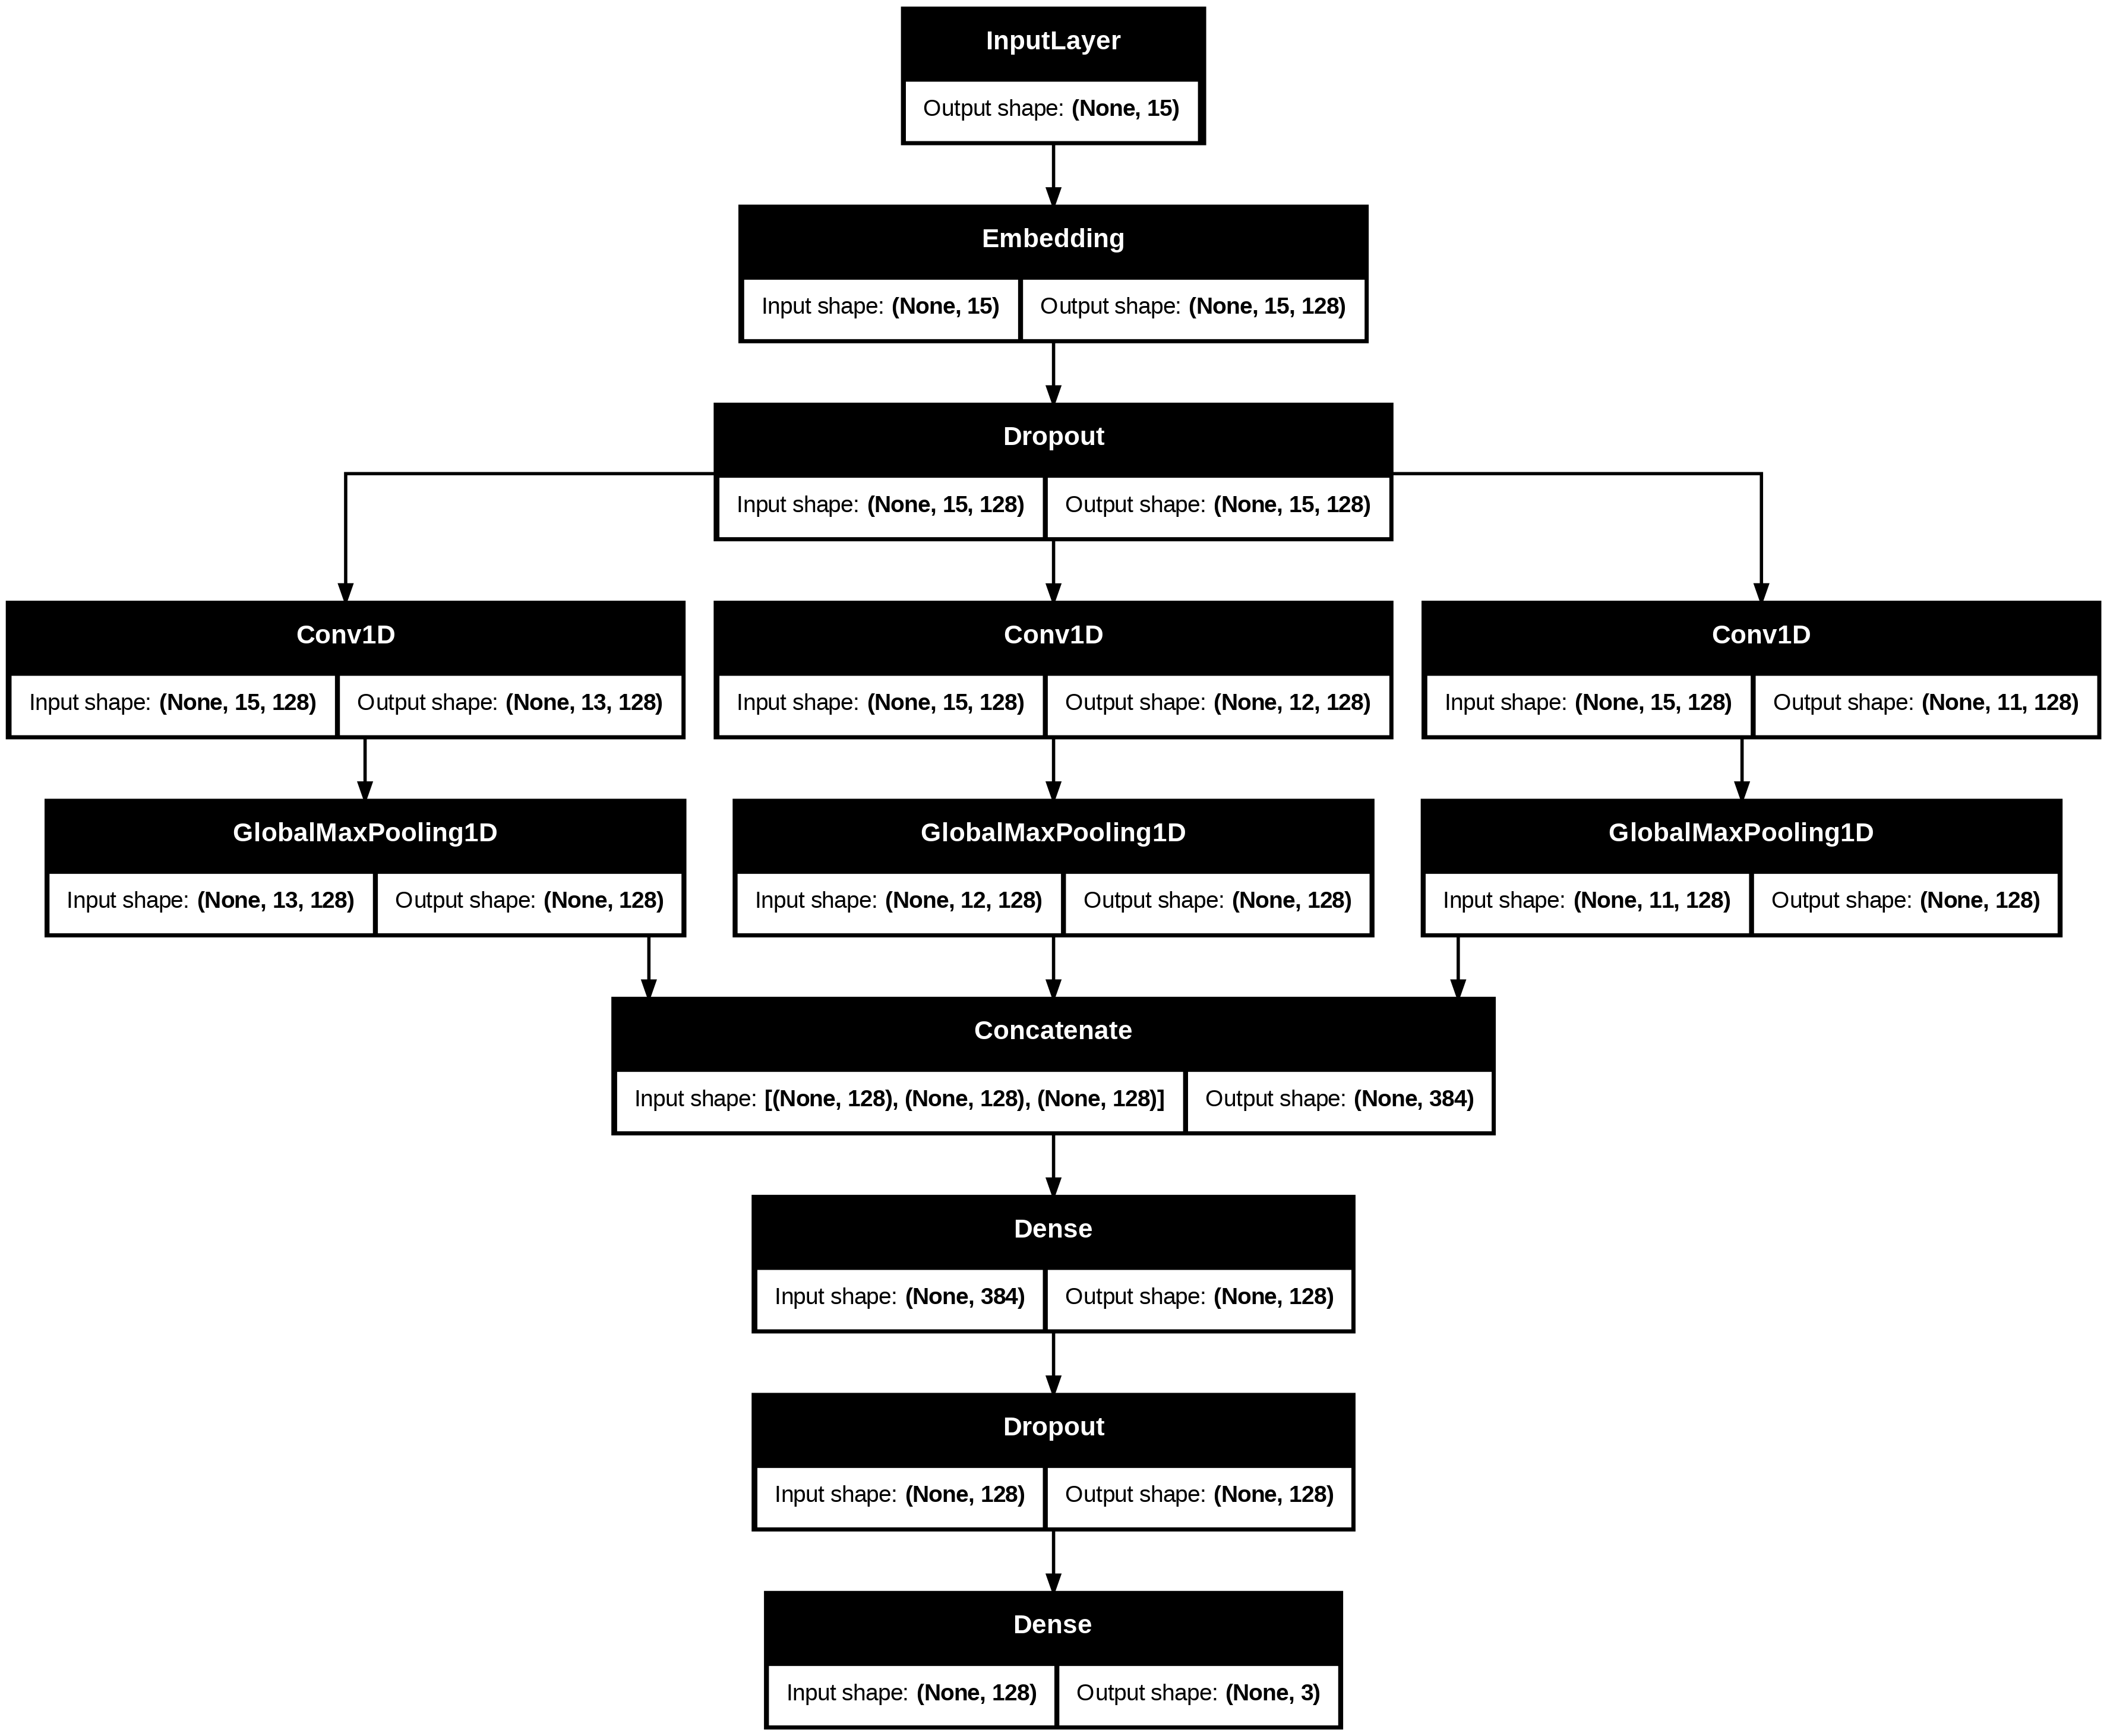

In [42]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 5.모델 학습

In [43]:
# 모델 생성후에는 컴파일
# optimizer : adam 사용
# loss func : sparse_categorical_crossentropy 사용
# 모델평가 metric : accuracy   <-- ※ loss  값만 확인하면 된다면 생략해도 됨.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [44]:
# fit(학습용 데이터셋, validation 데이터셋 ...)
# epochs=5   : 모델 학습을 5회 반복
# verbose=1  : 모델 학습과정 출력
model.fit(train_ds, validation_data=val_ds, epochs=EPOCH)

Epoch 1/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.5584 - loss: 0.8915 - val_accuracy: 0.8274 - val_loss: 0.5535
Epoch 2/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8026 - loss: 0.5208 - val_accuracy: 0.9141 - val_loss: 0.2844
Epoch 3/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8963 - loss: 0.3052 - val_accuracy: 0.9547 - val_loss: 0.1518
Epoch 4/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9377 - loss: 0.1939 - val_accuracy: 0.9679 - val_loss: 0.0889
Epoch 5/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9561 - loss: 0.1375 - val_accuracy: 0.9818 - val_loss: 0.0590


In [45]:
# epoch 가 진행되면서 loss 는 줄고 accuracy 는 증가하는 방향이 될거다

# 6.성능평가

In [46]:
# 모델 평가(테스트 데이터셋 이용)
loss, accuracy = model.evaluate(test_ds)
print('Accuracy: %f' % (accuracy * 100))
print('loss: %f' % (loss))

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9831 - loss: 0.0554
Accuracy: 98.309386
loss: 0.055372


# 7.저장하기

In [ ]:
# 학습된 모델도 저장하고
# 학습에 사용한 사전정보도 저장해야 한다

In [47]:
model_path = os.path.join(base_path, 'out', 'cnn_model.keras')
tokenizer_path = os.path.join(base_path, 'out', "cnn-model-tokenizer.json")

In [48]:
if not os.path.exists(os.path.join(base_path, 'out')):
  os.makedirs(os.path.join(base_path, 'out'))

## 모델 저장

In [49]:
# 모델 저장
model.save(model_path)

# 이후에는. 여기서 저장된 모델 파일을 불러와 문장 데이터의 감정 분류를 할 예정입니다

In [ ]:
# 모델뿐 아니라 사전 정보도 저장해야 한다


In [ ]:
# 예제에서 사용한 하이퍼 파라미터 값
#   - 합성곱 필터 크기 및 개수,
#   - 단어 임베딩 벡터 크기,
#   - 에포크 값
#   - 등등...

# 이들은 꼭 정답이 아닙니다. 많은 실험과 시행착오를 통해 최적의 파라미터를 찾아야 합니다.

## 사전 저장

In [ ]:
# tf.keras.preprocessing.text.Tokenizer를 저장하고 다시 불러오는 방법은
# json 또는 pickle 형식으로 할 수 있습니다.

# 📌 주의: Pickle 방식은 Python 버전, TensorFlow 버전에 따라 호환성 문제가 생길 수 있습니다.
# 그래서 json 방식이 더 권장되는 편이다, 특히! 모델 배포 시!

In [50]:
# JSON으로 저장


tokenizer_json = tokenizer.to_json()
with open(tokenizer_path, "w", encoding="utf-8") as f:
  f.write(tokenizer_json)

# 8.감정분류 모델 사용

## 모델 불러오기

In [51]:
model = None
tokenizer = None

In [52]:
# 모델 불러오기
model = keras.models.load_model(model_path)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 15, 128)   │  1,715,072 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 128)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 128)   │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 11, 128)   │     82,048 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,885,195 (22.45 MB)

 Trainable params: 1,961,731 (7.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,923,464 (14.97 MB)

## 사전 불러오기

In [53]:
from tensorflow.keras.preprocessing.text import tokenizer_from_json
import json

In [56]:
# JSON 파일 읽기
with open(tokenizer_path, "r", encoding="utf-8") as f:
    tokenizer_json = f.read()

# Tokenizer 복원
tokenizer = tokenizer_from_json(tokenizer_json)

print(tokenizer.word_index)  # 복원된 사전 정보

{'너무': 1, '좋아하는': 2, '거': 3, '싶어': 4, '같아': 5, '안': 6, '나': 7, '좀': 8, '사람': 9, '내가': 10, '싶다': 11, '어떻게': 12, '썸': 13, '왜': 14, '내': 15, '사람이': 16, '이별': 17, '것': 18, '잘': 19, '없어': 20, '수': 21, '오늘': 22, '자꾸': 23, '이제': 24, '있어': 25, '또': 26, '많이': 27, '다': 28, '있을까': 29, '헤어진지': 30, '해': 31, '다시': 32, '될까': 33, '여자친구가': 34, '남자친구가': 35, '더': 36, '진짜': 37, '정말': 38, '게': 39, '나를': 40, '뭐': 41, '좋아': 42, '할까': 43, '하고': 44, '하는': 45, '연애': 46, '있는': 47, '계속': 48, '힘드네': 49, '연락': 50, '이': 51, '나만': 52, '먹고': 53, '이렇게': 54, '있는데': 55, '못': 56, '날': 57, '혼자': 58, '다른': 59, '방법': 60, '타는': 61, '한': 62, '그': 63, '안돼': 64, '그냥': 65, '없는': 66, '돼': 67, '짝남이': 68, '좋겠다': 69, '선물': 70, '모르겠어': 71, '같이': 72, '나한테': 73, '같은데': 74, '싫어': 75, '친구가': 76, '마음이': 77, '짝사랑': 78, '가고': 79, '사랑': 80, '헤어진': 81, '많아': 82, '힘들어': 83, '연락이': 84, '줄': 85, '좋겠어': 86, '술': 87, '후': 88, '짝남': 89, '듯': 90, '좋은': 91, '좋을까': 92, '나는': 93, '보고': 94, '해도': 95, '할': 96, '사랑이': 97, '짝녀가': 98, '말': 99, '남자': 100, '참'

## 평가

In [57]:
# 모델 사용을 위한 테스트 데이터 생성
# 위에서 패딩 처리한 시퀀스(paddes_seqs) 벡터 리스트와 감정(labels) 리스트 전체를 Dataset 객체로 만듭니다.
# 그 다음에는 데이터를 랜덤으로 섞은 후 테스트용 데이터셋을 2000개 뽑아내 20개씩 배치 처리합니다

ds = tf.data.Dataset.from_tensor_slices((padded_seqs, labels))
ds = ds.shuffle(len(features), seed=42)
test_ds = ds.take(2000).batch(20)

In [58]:
loss, accuracy = model.evaluate(test_ds)  # Dataset 을 매개변수로 건내줌
print(loss, accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9805 - loss: 0.0613
0.06131148710846901 0.9804999828338623


## 예측

In [59]:
# 확인) 특정 인덱스의 데이터
i = 10212
print(corpus[i])
print(padded_seqs[i])
print(labels[i])


['썸', '타는', '여자가', '남사친', '만나러', '간다는데', '뭐라', '해']
[   13    61   127  4320  1333 12162   856    31     0     0     0     0
     0     0     0]
2


In [60]:
# 테스트용 데이터셋의 i번째 데이터 감정 예측
picks = [i]

predict = model.predict(padded_seqs[picks])
predict_class = tf.math.argmax(predict, axis=1)
print("감정 예측 점수 : ", predict)
print("감정 예측 클래스 : ", predict_class.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
감정 예측 점수 :  [[1.7985428e-08 2.6832835e-08 1.0000000e+00]]
감정 예측 클래스 :  [2]


In [ ]:
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
# 감정 예측 점수 :  [[1.3683496e-07 4.8404045e-06 9.9999499e-01]]
# 감정 예측 클래스 :  [2]

## 실제 데이터 예측

In [ ]:
# 임의의 문장에 대한 감정분류하려면?

# ★반드시, 학습에 사용한 정보 반드시 필요!
#     동일한 방식으로 토큰화.
#     Tokenizer 사용(단어사전정보) -> 인덱싱
#     패딩정보: MAX_SEQ_LEN

# padding 추가
# 모델 입력, 출력, 분류

In [93]:
# 0: 일상다반사
# 1 : 이별(부정)
# 2 : 사랑(긍정)
classes = ['일상', '부정적', '긍정적']

In [94]:
# 도전!
def pred(text):
  corpus = preprocessing.text.text_to_word_sequence(text)
  sequences = tokenizer.texts_to_sequences([corpus])

  padded_seqs = preprocessing.sequence.pad_sequences(
    sequences, maxlen=MAX_SEQ_LEN, padding='post'
  )

  predict = model.predict(padded_seqs)

  print(f'{text} -> {classes[predict.argmax()]}')

In [95]:
pred("내가 좋아하는 사람이 날 좋아했으면 좋겠어.")
# ↓ [출력예시]
# 내가 좋아하는 사람이 날 좋아했으면 좋겠어. -> 긍정적

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
내가 좋아하는 사람이 날 좋아했으면 좋겠어. -> 긍정적


In [98]:
sentences = [
    "가스불 켜놓고 나온거 같아",
    "어떻게 해야 여자친구가 제 진심을 알아줄까",
    "업무 스트레스 넘 심해",
    "남친이랑 뭐하고 놀지",
    "내가 좋아하는 사람이 날 좋아했으면 좋겠어.",
    "원본 데이터가 이상해요",
    "내가 최대한 잘해줘도 불만이 많아",
]

for sentence in sentences:
  pred(sentence)

# ↓ [출력예시]
# 가스불 켜놓고 나온거 같아 -> 일상
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
# 어떻게 해야 여자친구가 제 진심을 알아줄까 -> 부정적
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
# 업무 스트레스 넘 심해 -> 일상
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
# 남친이랑 뭐하고 놀지 -> 긍정적
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
# 내가 좋아하는 사람이 날 좋아했으면 좋겠어. -> 긍정적
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
# 원본 데이터가 이상해요 -> 부정적
# 1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
# 내가 최대한 잘해줘도 불만이 많아 -> 긍정적

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
정준이가 희준했어요 -> 부정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
가스불 켜놓고 나온거 같아 -> 일상
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
어떻게 해야 여자친구가 제 진심을 알아줄까 -> 부정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
업무 스트레스 넘 심해 -> 일상
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
남친이랑 뭐하고 놀지 -> 긍정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
내가 좋아하는 사람이 날 좋아했으면 좋겠어. -> 긍정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
원본 데이터가 이상해요 -> 부정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
내가 최대한 잘해줘도 불만이 많아 -> 긍정적
